In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import sys
sys.path.append("../")
from constants import *

In [3]:
items_df = pd.read_csv("../data1/items.csv")

In [4]:
len(items_df)

1982

In [5]:
items_df.head(10)

,ItemID,ItemName,ItemPrice
0,1001026,ชุดเซ็ท 1 น้ำดื่ม/มินิค๊อกเทล/มาม่าคัพ,51.0
1,1010019,ปากกาเขียนแผ่นใส E142M ดำ ลบไม่ได้*10,38.0
2,1010020,ปากกาเขียนแผ่นใส E142M แดง ลบไม่ได้*10,35.0
3,1010021,ปากกาเขียนแผ่นใส E142M นง.ลบไม่ได้*10,38.0
4,1010024,ปากกาเขียนแผ่นใส E152M เขียว,35.0
5,1010025,ปากกาเขียนแผ่นใส E141F นง.ลบไม่ได้,38.0
6,1010134,ปากกาเน้นข้อความ เพนเทล S512 - P ชมพู*12,23.0
7,1010254,ปากกา เพนเทล ENERGEL BLN75-A ดำ,47.0
8,1010255,ปากกา เพนเทล ENERGEL BLN75-B แดง,47.0
9,1010256,ปากกา เพนเทล ENERGEL BLN75-C นง*12,47.0


In [6]:
buy_df = pd.read_csv("../data1/user_buy99.csv")

In [7]:
len(buy_df)

21141

In [8]:
buy_df.head(10)

,UserID,Date,ItemID,Frequency
0,10593,2024-01-16,8290001.0,5.0
1,10593,2024-01-16,5230011.0,1.0
2,10593,2024-01-16,5410052.0,1.0
3,10593,2024-01-26,8290001.0,1.0
4,10593,2024-01-29,1010254.0,1.0
5,10593,2024-02-01,6550250.0,1.0
6,10593,2024-02-01,6390792.0,2.0
7,10593,2024-02-01,6590071.0,1.0
8,10593,2024-02-02,6590071.0,3.0
9,10593,2024-02-02,6390792.0,3.0


In [9]:
buy_df.sort_values(by=["Date"], inplace=True)
grouped_ratings = buy_df.groupby(by="UserID").agg(list)

In [10]:
# นับจำนวน Item ของแต่ละ UserID
user_counts = buy_df.groupby("UserID")["ItemID"].size().reset_index(name="Count1")

In [11]:
item_counts = buy_df.groupby("ItemID")["UserID"].size().reset_index(name="Count2")

In [12]:
item_counts

,ItemID,Count2
0,5.480001e-01,1
1,9.810005e-01,1
2,1.001026e+06,3
3,1.010019e+06,1
4,1.010020e+06,1
...,...,...
2257,9.995007e+06,5
2258,9.995013e+06,3
2259,9.999207e+06,1
2260,6.390102e+07,3


In [13]:
#items_id
item_counts.sort_values("Count2")

,ItemID,Count2
0,0.548,1
417,5020211.000,1
419,5030012.000,1
420,5030094.000,1
421,5030136.000,1
...,...,...
1809,6560027.000,142
2011,6650029.000,155
1881,6610032.000,172
1874,6610005.000,176


In [14]:
# sort  user_id
user_counts.sort_values("Count1") 

,UserID,Count1
197,74675,2
47,31842,2
44,31363,2
117,54524,3
96,49593,3
...,...,...
205,77145,326
253,80677,335
106,52568,345
255,80700,708


In [15]:
user_counts.sort_values("Count1")

,UserID,Count1
197,74675,2
47,31842,2
44,31363,2
117,54524,3
96,49593,3
...,...,...
205,77145,326
253,80677,335
106,52568,345
255,80700,708


In [17]:
item_counts.describe()

,ItemID,Count2
count,2.262000e+03,2262.000000
mean,5.672246e+06,9.346154
std,2.595063e+06,21.137133
min,5.480001e-01,1.000000
25%,5.160059e+06,2.000000
50%,6.390994e+06,4.000000
75%,6.517531e+06,10.000000
max,6.400032e+07,714.000000


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_42228\2180566138.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


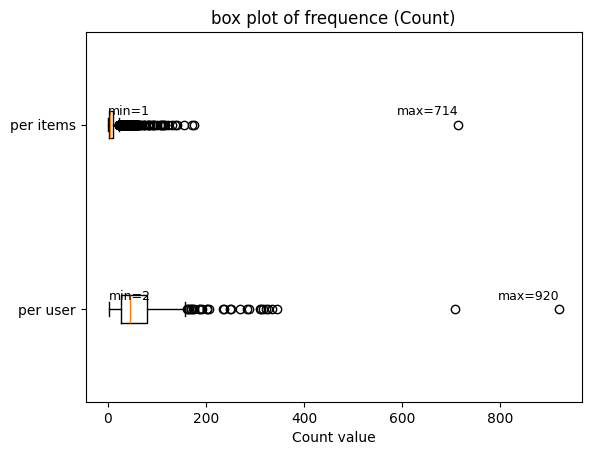

In [16]:
import matplotlib.pyplot as plt

data = [user_counts["Count1"], item_counts["Count2"]]
labels = ["per user", "per items"]

plt.figure()
bp = plt.boxplot(
    data,
    labels=labels,
    vert=False
)

# ใส่ label min / max
for i, d in enumerate(data, start=1):
    min_val = d.min()
    max_val = d.max()

    # y position ของ box แต่ละอัน
    y = i

    plt.text(min_val, y + 0.05, f"min={min_val}", fontsize=9, ha="left")
    plt.text(max_val, y + 0.05, f"max={max_val}", fontsize=9, ha="right")

plt.xlabel("Count value")
plt.title("box plot of frequence (Count)")
plt.show()

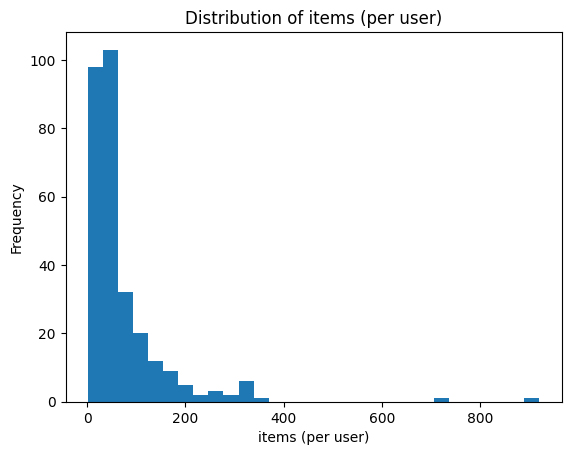

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(user_counts["Count1"], bins=30)
plt.xlabel("items (per user)")
plt.ylabel("Frequency")
plt.title("Distribution of items (per user)")
plt.show()

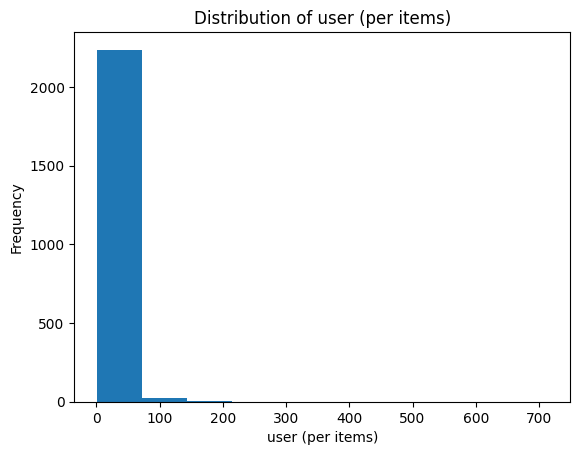

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(item_counts["Count2"], bins=10)
plt.xlabel("user (per items)")
plt.ylabel("Frequency")
plt.title("Distribution of user (per items)")
plt.show()

In [19]:
user_counts["Count1"].max()

920

In [20]:
mean_1 = user_counts["Count1"].median()
mean_2 = item_counts["Count2"].median()
print(mean_1,mean_2)

46.0 4.0


In [21]:
user_counts

,UserID,Count1
0,499,81
1,1562,22
2,1963,56
3,2215,57
4,2393,109
...,...,...
290,80861,8
291,80865,39
292,80867,27
293,80868,40


In [45]:
item_counts

,ItemID,Count2
0,5.480001e-01,1
1,9.810005e-01,1
2,1.001026e+06,3
3,1.010019e+06,1
4,1.010020e+06,1
...,...,...
2257,9.995007e+06,5
2258,9.995013e+06,3
2259,9.999207e+06,1
2260,6.390102e+07,3


In [66]:
# ลบ user ที่มี record น้อยกว่า 10
user_to_delete = user_counts[
    user_counts["Count1"] >= 10
]["UserID"].tolist()

# ลบ item ที่มี record น้อยกว่า 10 แต่ยกเว้น item 8290001
item_to_delete = item_counts[
    (item_counts["Count2"] >= 10) & (item_counts["ItemID"] != 8290001)
]["ItemID"].tolist()

In [67]:
user_to_delete

[499,
 1562,
 1963,
 2215,
 2393,
 2498,
 3402,
 4444,
 4688,
 6055,
 7031,
 8016,
 8269,
 10593,
 11877,
 11947,
 12347,
 13553,
 13581,
 15420,
 18225,
 20151,
 20823,
 21726,
 22016,
 22245,
 22822,
 23300,
 24058,
 24852,
 25632,
 25880,
 26756,
 29020,
 29107,
 29782,
 29819,
 29834,
 29864,
 30030,
 30569,
 31504,
 31623,
 33299,
 33650,
 34592,
 34674,
 34816,
 34837,
 35122,
 36099,
 36254,
 37230,
 37614,
 38048,
 38978,
 38981,
 39017,
 39160,
 40089,
 40547,
 41115,
 41163,
 41213,
 42275,
 42777,
 42826,
 43095,
 43097,
 43159,
 43180,
 43185,
 43193,
 44966,
 45072,
 45831,
 45874,
 46671,
 46699,
 46814,
 46817,
 46941,
 46964,
 47123,
 47406,
 47537,
 49312,
 49328,
 49329,
 50373,
 50494,
 51040,
 51064,
 51518,
 51619,
 51640,
 51729,
 51861,
 52568,
 53087,
 53406,
 53699,
 53808,
 53815,
 53915,
 53953,
 53978,
 54003,
 54006,
 54927,
 55146,
 55572,
 55699,
 55870,
 55878,
 55980,
 55995,
 56102,
 56128,
 56793,
 58044,
 58088,
 58187,
 58449,
 58450,
 58773,
 58856

In [68]:
item_to_delete = np.array(item_to_delete)
print(item_to_delete.shape)

(583,)


In [69]:
user_to_delete = np.array(user_to_delete)
print(user_to_delete.shape)

(279,)


In [ ]:
# len(item_to_delete)

In [70]:
# ลบ record ของ UserID เหล่านั้น
buy_df_filtered = buy_df[buy_df["UserID"].isin(user_to_delete)]
buy_df_filtered = buy_df_filtered[buy_df_filtered["ItemID"].isin(item_to_delete)]

In [71]:
buy_df_filtered

,UserID,Date,ItemID,Frequency
7736,78487,2024-01-02,6411154.0,1.0
13648,24852,2024-01-02,6610005.0,2.0
13649,24852,2024-01-02,6480210.0,2.0
20513,72682,2024-01-02,8170001.0,1.0
9256,8016,2024-01-02,6460017.0,1.0
...,...,...,...,...
5897,70651,2024-12-27,6380275.0,2.0
5895,70651,2024-12-27,6370001.0,4.0
5894,70651,2024-12-27,6480147.0,1.0
20499,66954,2024-12-27,6380243.0,1.0


In [72]:
grouped_ratings = buy_df_filtered.groupby(by="UserID").agg(list)

In [73]:
grouped_ratings.head(10)

,Date,ItemID,Frequency
UserID,,,
499,"[2024-01-23, 2024-01-23, 2024-01-23, 2024-01-2...","[6470055.0, 6630260.0, 6630245.0, 6630224.0, 6...","[1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
1562,"[2024-08-13, 2024-08-13, 2024-08-13, 2024-08-1...","[6390075.0, 6010043.0, 6390092.0, 6390020.0, 6...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 1.0, 1.0, ..."
1963,"[2024-01-19, 2024-04-02, 2024-04-02, 2024-05-3...","[6510093.0, 6480188.0, 6630032.0, 6560027.0, 6...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
2215,"[2024-01-24, 2024-01-24, 2024-01-25, 2024-01-2...","[6390046.0, 6390423.0, 4020002.0, 4040002.0, 4...","[1.0, 1.0, 2.0, 2.0, 2.0, 1.0, 1.0, 1.0, 1.0, ..."
2393,"[2024-01-05, 2024-01-05, 2024-01-05, 2024-01-0...","[9390012.0, 9390005.0, 9390002.0, 6380328.0, 6...","[1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, ..."
2498,"[2024-01-08, 2024-03-14, 2024-03-14, 2024-03-1...","[6650118.0, 6650118.0, 6480018.0, 6650022.0, 6...","[1.0, 1.0, 1.0, 1.0, 2.0, 4.0, 3.0, 1.0, 2.0, ..."
3402,"[2024-04-24, 2024-05-28, 2024-06-25, 2024-07-1...","[9390012.0, 9390012.0, 9390010.0, 9390012.0, 9...","[1.0, 1.0, 2.0, 1.0, 1.0, 2.0, 1.0, 1.0, 4.0, ..."
4444,"[2024-01-03, 2024-01-04, 2024-01-04, 2024-01-0...","[8170001.0, 6520037.0, 6470103.0, 6470031.0, 6...","[1.0, 1.0, 1.0, 1.0, 3.0, 1.0, 2.0, 1.0, 1.0, ..."
4688,"[2024-01-22, 2024-02-16, 2024-02-16, 2024-02-2...","[6520214.0, 6520214.0, 6420079.0, 6520214.0, 1...","[2.0, 2.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 3.0, ..."


In [74]:
buy_df_filtered["UserID"].size

14890

In [75]:
buy_df_filtered.to_csv("../data1/user_buy_expanded-3.csv", index=False)